In [7]:
import numpy as np
import matplotlib.pyplot as plt
from unyt import yr, Myr, Msun, angstrom
from synthesizer.parametric import SFH
from unyt import unyt_quantity
from synthesizer.parametric import SFH, Stars, ZDist
from synthesizer.grid import Grid
from unyt import yr, Myr, Msun, Gyr, unyt_quantity, Mpc

In [8]:
grid_name = "bpass-2.2.1-bin_chabrier03-0.1,300.0.hdf5"
grid_dir = "/Users/sw376/Dropbox/Research/data/synthesizer/grids/"

grid = Grid(grid_name, grid_dir=grid_dir, new_lam=np.logspace(3, 4.2, 1000) * angstrom)


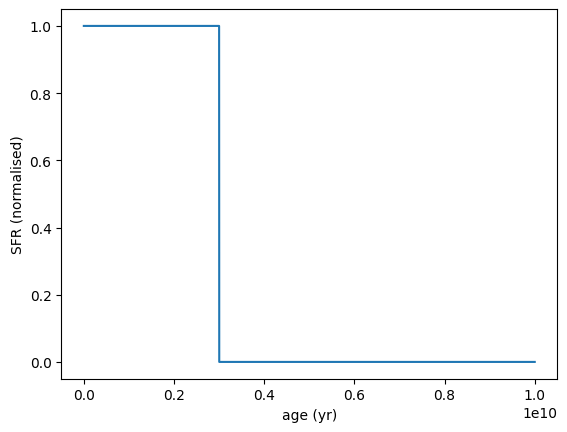

In [9]:

sfh = SFH.Constant(max_age=3E9*yr)

sfh.plot_sfh(t_range=(0, 1E10))


In [10]:
# Define a delta function for metallicity
metal_dist = ZDist.DeltaConstant(log10metallicity=-2.5)
print(metal_dist)

# Create the Stars object
stars = Stars(
    grid.log10ages,
    grid.metallicities,
    sf_hist=sfh,
    metal_dist=metal_dist,
    initial_mass=10**9 * Msun,
)

print(stars.calculate_surviving_mass(grid=grid).to("Msun"))
print(np.log10(stars.calculate_surviving_mass(grid=grid).to("Msun").value))

----------
SUMMARY OF PARAMETERISED METAL ENRICHMENT HISTORY
<class 'synthesizer.parametric.metal_dist.DeltaConstant'>
metallicity: None
log10metallicity: -2.5
----------

575013252.2690679 Msun
8.759677853943554


In [11]:
# Define a delta function for metallicity
metal_dist = ZDist.DeltaConstant(log10metallicity=-2.5)
print(metal_dist)

# Create the Stars object
stars = Stars(
    grid.log10ages,
    grid.metallicities,
    sf_hist=sfh,
    metal_dist=metal_dist,
)

print(stars.calculate_surviving_mass(grid=grid).to("Msun"))
print(np.log10(stars.calculate_surviving_mass(grid=grid).to("Msun").value))

----------
SUMMARY OF PARAMETERISED METAL ENRICHMENT HISTORY
<class 'synthesizer.parametric.metal_dist.DeltaConstant'>
metallicity: None
log10metallicity: -2.5
----------

1725039756.8416488 Msun
9.236799108671889


## Cosmic star formation history

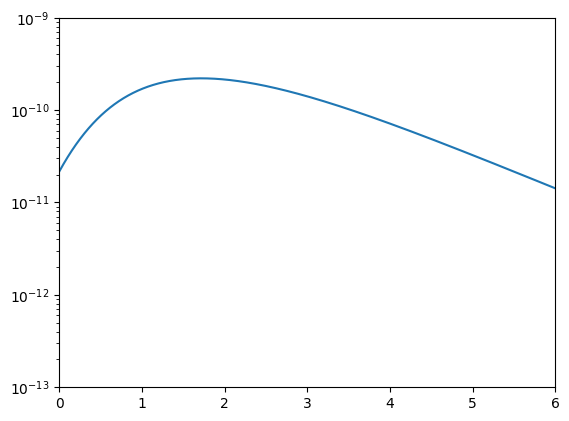

In [12]:
from astropy.cosmology import Planck18 as cosmo
from astropy.cosmology import z_at_value
import astropy.units as u

age_of_universe = unyt_quantity(cosmo.age(0).value, str(cosmo.age(0).unit))
sfh = SFH.LogNormal(tau=0.6, peak_age=1e10 * yr, max_age=age_of_universe)
# sfh.plot_sfh(t_range=(0, age_of_universe.to(yr).value), log=True)


age = np.linspace(1E7, age_of_universe.to('yr').value - 1E8, 1000)

redshift = z_at_value(cosmo.lookback_time, age * u.yr)

sfr = sfh.get_sfr(age)

plt.plot(redshift, sfr)
# plt.xscale('log')
plt.yscale('log')
plt.xlim(0, 6)
plt.ylim(1e-13, 1e-9)
plt.show()

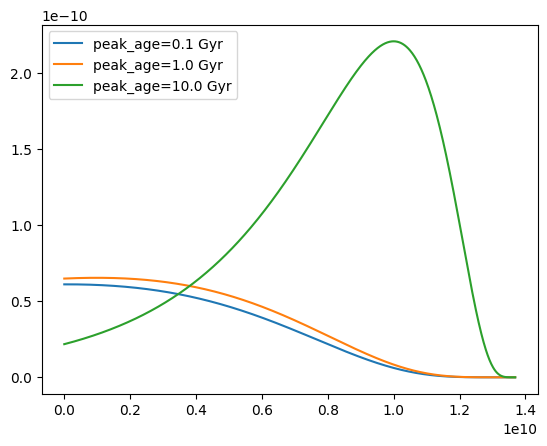

In [16]:
from astropy.cosmology import Planck18 as cosmo
from astropy.cosmology import z_at_value
import astropy.units as u

age_of_universe = unyt_quantity(cosmo.age(0).value, str(cosmo.age(0).unit))

age = np.linspace(1E7, age_of_universe.to('yr').value - 1E8, 1000)

for peak_age in [1e8, 1e9, 1e10] * yr:
    sfh = SFH.LogNormal(tau=0.6, peak_age=peak_age, max_age=age_of_universe)
    plt.plot(age, sfh.get_sfr(age), label=f"peak_age={peak_age.to('Gyr')}")
plt.legend()
plt.show()